In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
file_path = "C:\\Users\\sriti\\Downloads\\global air pollution dataset.csv"
data = pd.read_csv(file_path)

# Understanding dataset structure
data.head()  # shows first 5 rows  

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


In [5]:
 print(data.info()) # shows columns and data types

<class 'pandas.DataFrame'>
RangeIndex: 23463 entries, 0 to 23462
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Country             23036 non-null  str  
 1   City                23462 non-null  str  
 2   AQI Value           23463 non-null  int64
 3   AQI Category        23463 non-null  str  
 4   CO AQI Value        23463 non-null  int64
 5   CO AQI Category     23463 non-null  str  
 6   Ozone AQI Value     23463 non-null  int64
 7   Ozone AQI Category  23463 non-null  str  
 8   NO2 AQI Value       23463 non-null  int64
 9   NO2 AQI Category    23463 non-null  str  
 10  PM2.5 AQI Value     23463 non-null  int64
 11  PM2.5 AQI Category  23463 non-null  str  
dtypes: int64(5), str(7)
memory usage: 2.1 MB
None


In [6]:

# ================================
# DATA UNDERSTANDING
# ================================
# describe() gives statistical summary like mean, min, max
data.describe()






,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
count,23463.000000,23463.000000,23463.000000,23463.000000,23463.000000
mean,72.010868,1.368367,35.193709,3.063334,68.519755
std,56.055220,1.832064,28.098723,5.254108,54.796443
min,6.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,1.000000,21.000000,0.000000,35.000000
50%,55.000000,1.000000,31.000000,1.000000,54.000000
75%,79.000000,1.000000,40.000000,4.000000,79.000000
max,500.000000,133.000000,235.000000,91.000000,500.000000


In [7]:

# ================================
# HANDLE MISSING VALUES
# ================================
print(data.isnull().sum())
# Filling missing values only for numeric columns
data.fillna(data.mean(numeric_only=True), inplace=True)

# Verify again
print(data.isnull().sum())




Country               427
City                    1
AQI Value               0
AQI Category            0
CO AQI Value            0
CO AQI Category         0
Ozone AQI Value         0
Ozone AQI Category      0
NO2 AQI Value           0
NO2 AQI Category        0
PM2.5 AQI Value         0
PM2.5 AQI Category      0
dtype: int64
Country               427
City                    1
AQI Value               0
AQI Category            0
CO AQI Value            0
CO AQI Category         0
Ozone AQI Value         0
Ozone AQI Category      0
NO2 AQI Value           0
NO2 AQI Category        0
PM2.5 AQI Value         0
PM2.5 AQI Category      0
dtype: int64


In [8]:
# DATA CLEANING
# ================================
# Removing duplicate rows
data.drop_duplicates(inplace=True)

print("Rows after cleaning:", len(data))


Rows after cleaning: 23463


In [9]:
# ================================
# NUMPY OPERATIONS
# ================================
# Converting AQI column to NumPy array
aqi_array = data['AQI Value'].values

# Basic NumPy operations
print("Mean AQI:", np.mean(aqi_array))
print("Max AQI:", np.max(aqi_array))
print("Min AQI:", np.min(aqi_array))


Mean AQI: 72.01086817542513
Max AQI: 500
Min AQI: 6


In [10]:
# ================================
# PANDAS MANIPULATION
# ================================
# Creating category based on AQI
data['AQI_Category'] = np.where(data['AQI Value'] > data['AQI Value'].mean(), 'High', 'Low')

print(data[['AQI Value', 'AQI_Category']].head())


   AQI Value AQI_Category
0         51          Low
1         41          Low
2         66          Low
3         34          Low
4         22          Low


In [11]:
# ================================
# DATE CONVERSION (IMPORTANT)
# ================================
# Convert Date column if present
if 'Date' in data.columns:
    data['Date'] = pd.to_datetime(data['Date'])

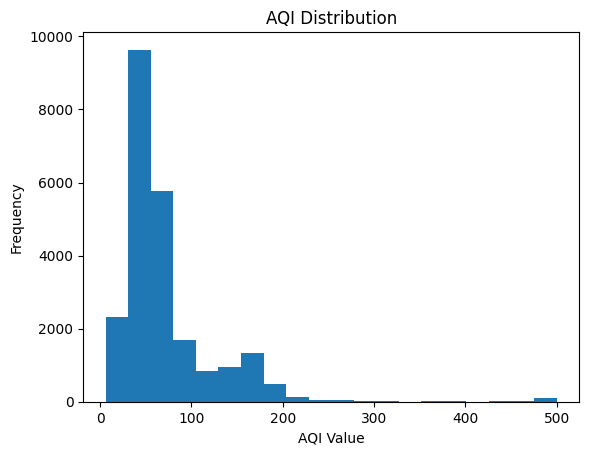

In [12]:
# ================================
# VISUALIZATION (MATPLOTLIB)
# ================================

# Histogram (AQI distribution)
plt.hist(data['AQI Value'], bins=20)
plt.title("AQI Distribution")
plt.xlabel("AQI Value")
plt.ylabel("Frequency")
plt.show()

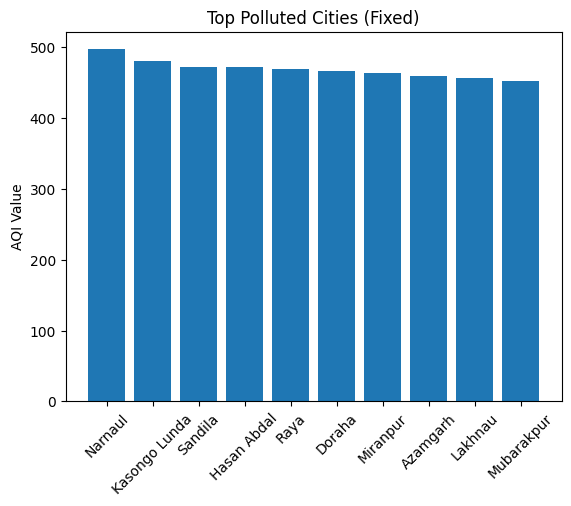

In [34]:
# Keep max AQI per city (important)
data_unique = data.sort_values(by='AQI Value', ascending=False).drop_duplicates(subset='City')

# REMOVE capped values (this is the real fix)
data_filtered = data_unique[data_unique['AQI Value'] < 500]

# Now plot
top_cities = data_filtered.head(10)

plt.bar(top_cities['City'], top_cities['AQI Value'])
plt.xticks(rotation=45)
plt.title("Top Polluted Cities (Fixed)")
plt.ylabel("AQI Value")
plt.show()

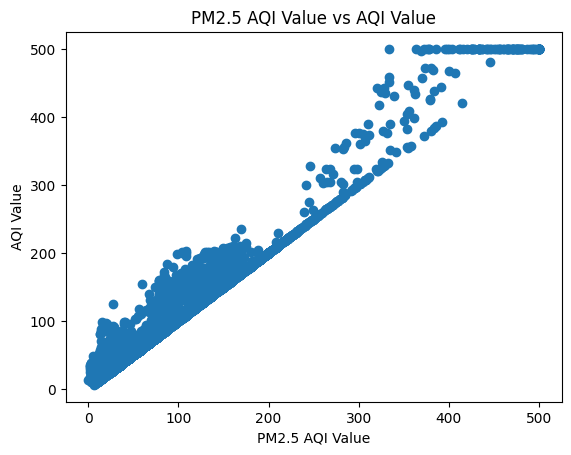

In [14]:
# Scatter plot (PM2.5 vs AQI)
plt.scatter(data['PM2.5 AQI Value'], data['AQI Value'])
plt.xlabel("PM2.5 AQI Value")
plt.ylabel("AQI Value")
plt.title("PM2.5 AQI Value vs AQI Value")
plt.show()


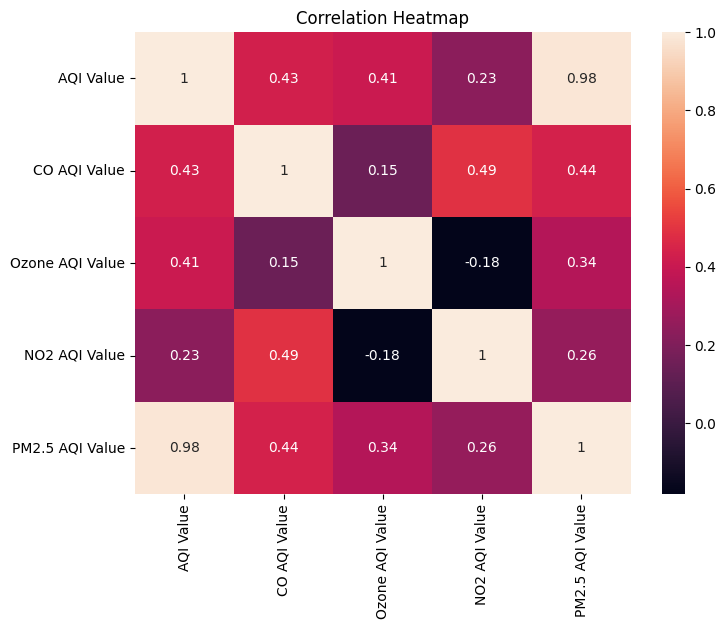

In [15]:
# ================================
# SEABORN VISUALIZATION
# ================================

# Correlation heatmap
corr = data.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

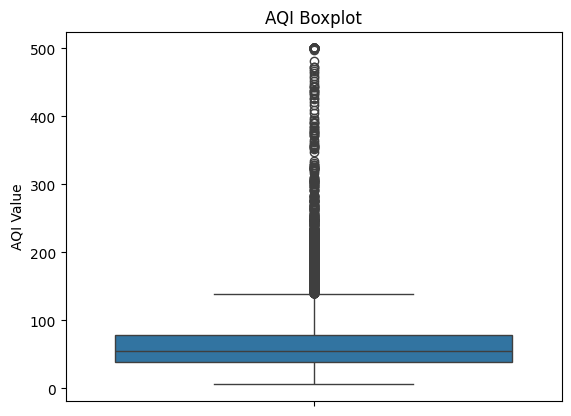

In [16]:
# Boxplot (Outlier detection)
sns.boxplot(data['AQI Value'])
plt.title("AQI Boxplot")
plt.show()


In [17]:
# EDA (EXPLORATORY DATA ANALYSIS)
# ================================

# Summary statistics
print(data['AQI Value'].describe())

count    23463.000000
mean        72.010868
std         56.055220
min          6.000000
25%         39.000000
50%         55.000000
75%         79.000000
max        500.000000
Name: AQI Value, dtype: float64


In [18]:
# Correlation (AQI vs PM2.5)
corr_value = data['AQI Value'].corr(data['PM2.5 AQI Value'])
print("Correlation AQI Value vs PM2.5 AQI Value:", corr_value)


Correlation AQI Value vs PM2.5 AQI Value: 0.9843265891583709


In [19]:
# OUTLIER DETECTION (IQR METHOD)
# ================================
Q1 = data['AQI Value'].quantile(0.25)
Q3 = data['AQI Value'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[(data['AQI Value'] < lower) | (data['AQI Value'] > upper)]

print("Number of outliers:", len(outliers))


Number of outliers: 2935


In [20]:
# IMPORT REQUIRED LIBRARIES
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [21]:
# -------------------------------
# SELECT FEATURES AND TARGET
# -------------------------------
# Features (independent variables)
X = data[['PM2.5 AQI Value' , 'NO2 AQI Value', 'CO AQI Value', 'Ozone AQI Value']]

In [22]:
# -------------------------------
# TARGET (dependent variable)
# -------------------------------
y = data['AQI Value']

In [23]:
# -------------------------------
# TRAIN-TEST SPLIT
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
# -------------------------------
# MODEL
# -------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
# -------------------------------
# PREDICTION
# -------------------------------
y_pred = model.predict(X_test)

In [26]:
# EVALUATION
# -------------------------------
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9758391044397207


In [27]:
# ================================
# INTERACTION MODEL (FIXED)
# ================================

# Create interaction features
data['PM25_NO2'] = data['PM2.5 AQI Value'] * data['NO2 AQI Value']
data['PM25_CO'] = data['PM2.5 AQI Value'] * data['CO AQI Value']

# Feature set
X_interaction = data[['PM2.5 AQI Value', 
                      'NO2 AQI Value', 
                      'CO AQI Value', 
                      'Ozone AQI Value',
                      'PM25_NO2',
                      'PM25_CO']]

# Target
y = data['AQI Value']

# Split
from sklearn.model_selection import train_test_split
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_interaction, y, test_size=0.2, random_state=42
)

# Model
from sklearn.linear_model import LinearRegression
model_interaction = LinearRegression()
model_interaction.fit(X_train_i, y_train_i)

# Prediction
y_pred_i = model_interaction.predict(X_test_i)

# Evaluation
from sklearn.metrics import r2_score
r2_interaction = r2_score(y_test_i, y_pred_i)

print("R2 Score with Interaction:", r2_interaction)

R2 Score with Interaction: 0.9759273800315575


In [28]:
# ================================
# MODEL COMPARISON TABLE
# ================================

results = pd.DataFrame({
    'Model': ['Basic Linear Regression', 'With Interaction Features'],
    'R2 Score': [r2, r2_interaction]
})

print(results)

                       Model  R2 Score
0    Basic Linear Regression  0.975839
1  With Interaction Features  0.975927


In [29]:
# ================================
# EFFECT OF 10% INCREASE IN PM2.5
# ================================

# Take a sample from test data
sample = X_test.copy()

# Predict original AQI
original_pred = model.predict(sample)

# Increase PM2.5 by 10%
sample_increased = sample.copy()
sample_increased['PM2.5 AQI Value'] = sample_increased['PM2.5 AQI Value'] * 1.10

# Predict new AQI
new_pred = model.predict(sample_increased)

# Calculate change
change = new_pred - original_pred

# Average change
avg_change = change.mean()

print("Average change in AQI when PM2.5 increases by 10%:", avg_change)

Average change in AQI when PM2.5 increases by 10%: 6.6353551864330855
